# SuperPoint + LightGlue benchmark

This Kaggle notebook installs LightGlue, selects two Sentinel-2 scenes from the uploaded inputs, runs the tiled project benchmark, saves `benchmark.csv`, and displays the strongest-tile correspondence visualization.

## Configuration

Set `LEFT_PATH` and `RIGHT_PATH` only when automatic same-tile scene selection is not appropriate.

In [12]:
from pathlib import Path
import re
import shutil

INPUT_ROOT = Path('/kaggle/input')
PROJECT_ROOT = Path('/kaggle/working')
CODE_ROOT = PROJECT_ROOT / 'src' / 'sentinel_matching'
OUTPUT_ROOT = PROJECT_ROOT / 'lightglue_output'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
BANDS = 'B04,B03,B02'
TILE_SIZE = 1024
OVERLAP = 128
RANSAC_THRESHOLD = 3.0
DEVICE = 'cuda'
LEFT_PATH = None
RIGHT_PATH = None

archives = sorted({path.parent for path in INPUT_ROOT.rglob('deep_matchers.py') if path.parent.name == 'sentinel_matching'}, key=str)
SOURCE_ROOT = archives[0] if archives else None
if SOURCE_ROOT is None:
    print('code_found=False; upload the sentinel_matching archive as a Kaggle dataset.')
else:
    shutil.copytree(SOURCE_ROOT, CODE_ROOT, dirs_exist_ok=True)
    print(f'code_found=True\ncode_root={CODE_ROOT}')

code_found=True
code_root=/kaggle/working/src/sentinel_matching


## Install LightGlue

Internet must be enabled. `--no-deps` preserves Kaggle's CUDA-compatible PyTorch installation while downloading the official LightGlue package and its pretrained SuperPoint weights on first inference.

In [13]:
if SOURCE_ROOT is not None:
    !python -m pip install -q --no-deps git+https://github.com/cvg/LightGlue.git@eb42fee2d71449efb0aa5c10549752b5d75384d8
    import cv2
    import rasterio
    import torch
    from lightglue import LightGlue, SuperPoint
    print(f'lightglue_ready=True\ntorch={torch.__version__}\ncuda_available={torch.cuda.is_available()}')
else:
    print('lightglue_installation_skipped=True')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
lightglue_ready=True
torch=2.10.0+cu128
cuda_available=True


## Select a scene pair

The notebook prefers two `.SAFE` directories with the same Sentinel MGRS tile identifier; otherwise it uses the first two scenes.

In [14]:
def find_safe_scenes(root):
    return sorted((path.resolve() for path in root.rglob('*.SAFE') if path.is_dir()), key=str)

def choose_pair(scenes, left_override, right_override):
    if left_override and right_override and Path(left_override).is_dir() and Path(right_override).is_dir():
        return Path(left_override), Path(right_override)
    groups = {}
    for scene in scenes:
        match = re.search(r'_T(\d{2}[A-Z]{3})_', scene.name.upper())
        groups.setdefault(match.group(1) if match else 'unknown', []).append(scene)
    for group in groups.values():
        if len(group) >= 2:
            return group[0], group[1]
    return (scenes[0], scenes[1]) if len(scenes) >= 2 else (None, None)

SAFE_SCENES = find_safe_scenes(INPUT_ROOT)
LEFT, RIGHT = choose_pair(SAFE_SCENES, LEFT_PATH, RIGHT_PATH)
PAIR_READY = LEFT is not None and RIGHT is not None
print(f'safe_scenes={len(SAFE_SCENES)}')
print(f'left={LEFT}')
print(f'right={RIGHT}')

safe_scenes=50
left=/kaggle/input/datasets/isaienkov/deforestation-in-ukraine/S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510/S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510.SAFE
right=/kaggle/input/datasets/isaienkov/deforestation-in-ukraine/S2A_MSIL1C_20160330T082542_N0201_R021_T36UYA_20160330T082810/S2A_MSIL1C_20160330T082542_N0201_R021_T36UYA_20160330T082810.SAFE


## SuperPoint + LightGlue benchmark

SuperPoint extracts learned keypoints and descriptors, LightGlue matches them, and RANSAC retains geometrically consistent matches. The same tile size, overlap, and threshold can be used for a fair comparison with SIFT, ORB, and LoFTR.

In [15]:
OUTPUT_IMAGE = OUTPUT_ROOT / 'superpoint_lightglue_best_tile.png'
METRICS_CSV = OUTPUT_ROOT / 'benchmark.csv'
if SOURCE_ROOT is not None and PAIR_READY:
    !python src/sentinel_matching/benchmark_matching.py --left "{LEFT}" --right "{RIGHT}" --methods superpoint_lightglue --bands "{BANDS}" --tile-size {TILE_SIZE} --overlap {OVERLAP} --ransac-threshold {RANSAC_THRESHOLD} --device "{DEVICE}" --output-dir "{OUTPUT_ROOT}"
else:
    print('lightglue_run_skipped=True')

SUPERPOINT_LIGHTGLUE tiles: 100%|█████████████| 169/169 [00:23<00:00,  7.27it/s]
{'method': 'superpoint_lightglue', 'keypoints_left': 345507, 'keypoints_right': 180317, 'candidate_matches': 8377, 'inlier_matches': 4298, 'inlier_ratio': 0.5130715053121643, 'inference_time_seconds': 23.39754873600009, 'visualization': '/kaggle/working/lightglue_output/superpoint_lightglue_best_tile.png'}
results=/kaggle/working/lightglue_output/benchmark.csv


## Benchmark metrics and visualization

The CSV contains candidate matches, geometrically verified inliers, inlier ratio, runtime, and the visualization path for the selected scene pair.

,method,keypoints_left,keypoints_right,candidate_matches,inlier_matches,inlier_ratio,inference_time_seconds,visualization
0,superpoint_lightglue,345507,180317,8377,4298,0.513072,23.397549,/kaggle/working/lightglue_output/superpoint_li...


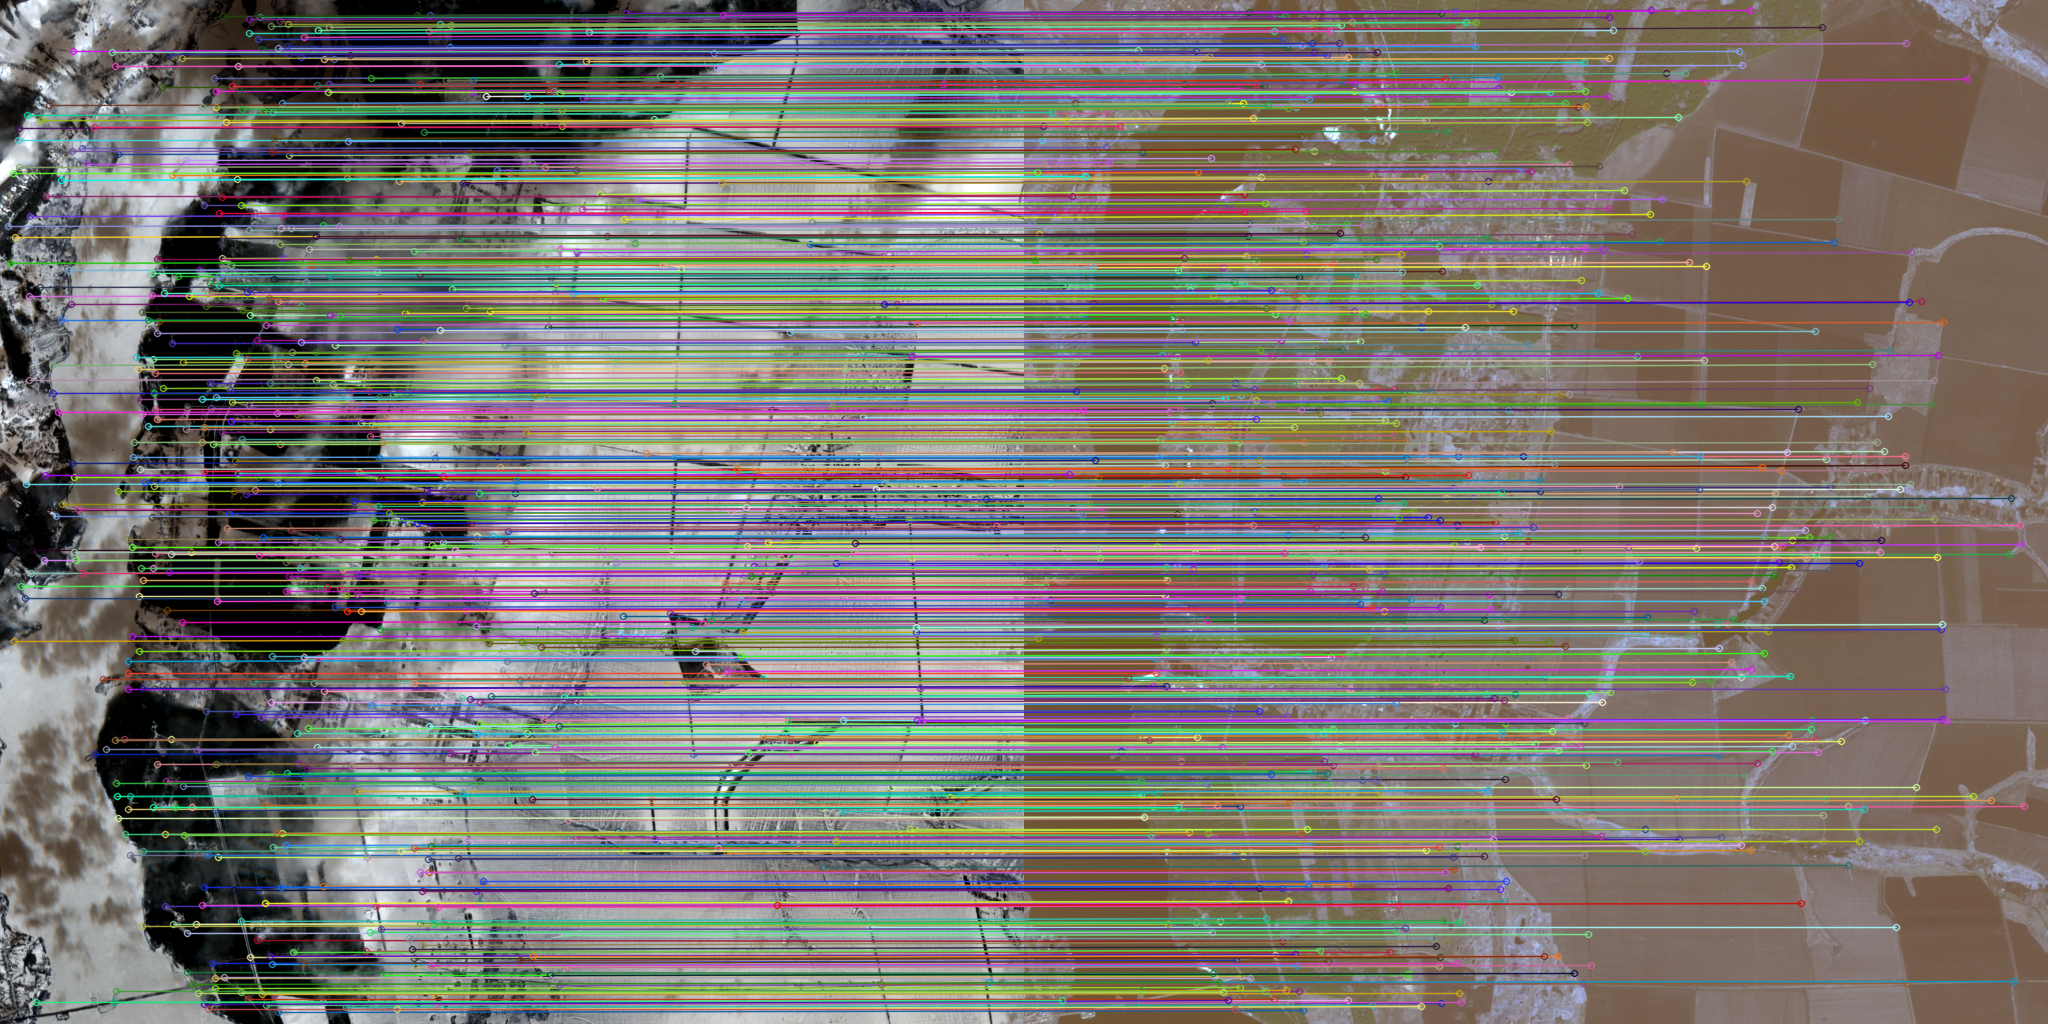

result_image=/kaggle/working/lightglue_output/superpoint_lightglue_best_tile.png


In [16]:
import pandas as pd
from IPython.display import Image, display

if METRICS_CSV.is_file():
    display(pd.read_csv(METRICS_CSV))
else:
    print('metrics_csv_not_found=True')

if OUTPUT_IMAGE.is_file():
    display(Image(filename=str(OUTPUT_IMAGE)))
    print(f'result_image={OUTPUT_IMAGE}')
else:
    print('result_image_not_found=True')